In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("indian_roads_dataset.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (20000, 24)
   accident_id        city        state   latitude  longitude        date  \
0            0        Pune  Maharashtra  18.680827  73.930388  2023-10-22   
1            1      Mumbai  Maharashtra  18.817732  72.790846  2023-05-21   
2            2      Mumbai  Maharashtra  19.096889  72.819424  2024-07-10   
3            3  Chandigarh       Punjab  30.787805  76.847507  2025-03-30   
4            4     Chennai   Tamil Nadu  12.965155  80.283313  2024-01-25   

    time  hour day_of_week  is_weekend  ... visibility  temperature  \
0   5:00     5      Sunday           1  ...        low           32   
1   4:00     4      Sunday           1  ...       high           34   
2  13:00    13   Wednesday           0  ...        low           21   
3  11:00    11      Sunday           1  ...        low           30   
4  16:00    16    Thursday           0  ...       high           24   

   traffic_density        cause accident_severity  vehicles_involved  \
0             high 

In [3]:
df = df.drop(columns=['accident_id', 'date', 'time', 'latitude', 'longitude', 'city', 'state'])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'festival', 'risk_score']


In [4]:
print("Null values:\n", df.isnull().sum())
df = df.drop_duplicates()
print("\nShape after removing duplicates:", df.shape)

Null values:
 hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

Shape after removing duplicates: (20000, 17)


In [5]:
categorical_cols = ['day_of_week', 'road_type', 'weather', 'visibility',
                    'traffic_density', 'cause', 'festival']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Encode target separately
le_target = LabelEncoder()
df['accident_severity'] = le_target.fit_transform(df['accident_severity'])

print("Classes:", le_target.classes_)
print(df.head())

Classes: ['fatal' 'major' 'minor']
   hour  day_of_week  is_weekend  road_type  lanes  traffic_signal  weather  \
0     5            3           1          0      3               1        1   
1     4            3           1          2      4               0        0   
2    13            6           0          2      3               0        1   
3    11            3           1          2      1               1        1   
4    16            4           0          0      3               1        0   

   visibility  temperature  traffic_density  cause  accident_severity  \
0           1           32                0      4                  0   
1           0           34                1      4                  1   
2           1           21                2      4                  2   
3           1           30                0      0                  2   
4           0           24                1      0                  2   

   vehicles_involved  casualties  is_peak_hour  fes

In [6]:
X = df.drop(columns=['accident_severity'])
y = df['accident_severity']

print("X shape:", X.shape)
print("Class distribution:\n", y.value_counts())

X shape: (20000, 16)
Class distribution:
 accident_severity
2    11025
1     5988
0     2987
Name: count, dtype: int64


In [7]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {2: 11025, 1: 5988, 0: 2987}
After SMOTE: {0: 11025, 1: 11025, 2: 11025}


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (26460, 16)
Testing size: (6615, 16)


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [10]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

y_pred_gnb = gnb.predict(X_test_scaled)

print("=== Gaussian Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gnb, target_names=le_target.classes_))

=== Gaussian Naive Bayes ===
Accuracy: 0.5519274376417234

Classification Report:
               precision    recall  f1-score   support

       fatal       0.67      0.71      0.69      2200
       major       0.46      0.60      0.52      2196
       minor       0.55      0.34      0.42      2219

    accuracy                           0.55      6615
   macro avg       0.56      0.55      0.54      6615
weighted avg       0.56      0.55      0.54      6615



In [11]:
# Multinomial NB needs non-negative values so we use original unscaled data
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

y_pred_mnb = mnb.predict(X_test)

print("=== Multinomial Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_mnb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_mnb, target_names=le_target.classes_))

=== Multinomial Naive Bayes ===
Accuracy: 0.49493575207860924

Classification Report:
               precision    recall  f1-score   support

       fatal       0.58      0.63      0.60      2200
       major       0.43      0.48      0.45      2196
       minor       0.48      0.38      0.42      2219

    accuracy                           0.49      6615
   macro avg       0.49      0.50      0.49      6615
weighted avg       0.49      0.49      0.49      6615



In [12]:
gnb_acc = accuracy_score(y_test, y_pred_gnb)
mnb_acc = accuracy_score(y_test, y_pred_mnb)

print("Gaussian NB Accuracy  :", round(gnb_acc * 100, 2), "%")
print("Multinomial NB Accuracy:", round(mnb_acc * 100, 2), "%")

if gnb_acc > mnb_acc:
    print("\n✅ Gaussian Naive Bayes performs BETTER!")
else:
    print("\n✅ Multinomial Naive Bayes performs BETTER!")

Gaussian NB Accuracy  : 55.19 %
Multinomial NB Accuracy: 49.49 %

✅ Gaussian Naive Bayes performs BETTER!


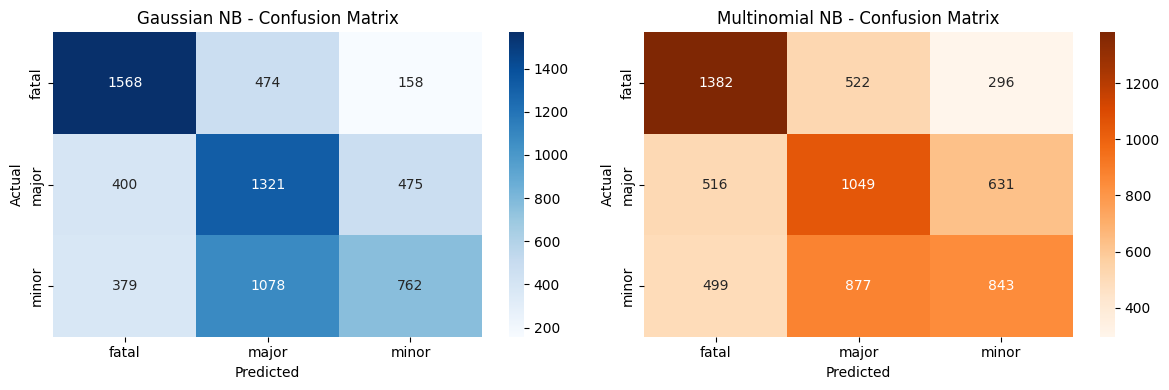

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_gnb = confusion_matrix(y_test, y_pred_gnb)
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_, ax=axes[0])
axes[0].set_title("Gaussian NB - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_mnb = confusion_matrix(y_test, y_pred_mnb)
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_, ax=axes[1])
axes[1].set_title("Multinomial NB - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [14]:
print("Sample predictions using Best Model:\n")
print(f"{'Actual':<15} {'Predicted':<15}")
print("-" * 30)

for actual, predicted in zip(y_test[:10], y_pred_gnb[:10]):
    actual_name    = le_target.classes_[actual]
    predicted_name = le_target.classes_[predicted]
    match = "✅" if actual == predicted else "❌"
    print(f"{actual_name:<15} {predicted_name:<15} {match}")

Sample predictions using Best Model:

Actual          Predicted      
------------------------------
minor           major           ❌
fatal           fatal           ✅
fatal           fatal           ✅
minor           major           ❌
minor           major           ❌
fatal           fatal           ✅
major           fatal           ❌
major           minor           ❌
minor           minor           ✅
fatal           fatal           ✅
